# Week 5 - Support Vector Machines

In [37]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## First Dataset: Acute Kidney

**Training SVM on Acute Kidney dataset**

In [39]:
# 1) Load data
url = "https://raw.githubusercontent.com/muathdb/Week4/main/Acute%20Kidney.csv"
df = pd.read_csv(url)   # add encoding="utf-8-sig" if you see weird characters

# 2) Choose your target column (CHANGE THIS to what you actually have)
# Common possibilities in this dataset style:
# 'aki', 'aki_stage', 'mortality', 'death', 'outcome', 'renal_replacement', 'icu_mortality'
CANDIDATES = ["aki", "aki_stage", "mortality", "death", "outcome"]
target = next((c for c in CANDIDATES if c in df.columns), None)
if target is None:
    raise ValueError(f"Please set `target` to your label column. Columns available: {list(df.columns)}")

# If the target looks categorical text (e.g., 'Yes'/'No'), coerce to 0/1
if df[target].dtype == 'object':
    # Try a generic yes/no mapping; adjust if needed
    mapping = {"yes": 1, "y": 1, "true": 1, "t": 1, "1": 1,
               "no": 0, "n": 0, "false": 0, "f": 0, "0": 0}
    y = df[target].astype(str).str.lower().map(mapping)
    # If mapping failed (NaNs), try factorize to binary 0/1
    if y.isna().any():
        y, uniques = pd.factorize(df[target])
        if len(uniques) != 2:
            raise ValueError(f"Target '{target}' has {len(uniques)} classes ({list(uniques)}). "
                             "SVM example below expects a binary task.")
else:
    y = df[target].astype(int) if df[target].nunique() <= 5 else df[target]

# 3) Feature matrix
# Drop obvious ID-like columns if present to avoid leakage/high-cardinality noise
ID_LIKE = [c for c in ["subject_id","hadm_id","stay_id","patient_id","icustay_id","adm_id"] if c in df.columns]
X = df.drop(columns=[target] + ID_LIKE)

# 4) Split columns by type
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

# 5) Preprocess: impute + scale numerics; impute + one-hot categoricals
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

# 6) SVM model (RBF by default). class_weight='balanced' helps with class imbalance.
svc = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=False)

# Full pipeline
clf = Pipeline(steps=[("preprocess", preprocess),
                     ("model", svc)])

# 7) Train/test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 8) Quick fit
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# 9) (Optional) Explore kernels & regularization (C) via grid search
# Note: this can take a few minutes on large data
param_grid = {
    "model__kernel": ["linear", "rbf", "poly"],
    "model__C": [0.1, 1, 10],
    # gamma only relevant for rbf/poly; 'scale' is usually a good default
}
search = GridSearchCV(
    clf, param_grid=param_grid, scoring="f1" if len(np.unique(y))==2 else "accuracy",
    cv=5, n_jobs=-1
)
search.fit(X_train, y_train)
print("\nBest params:", search.best_params_)
print("Best CV score:", round(search.best_score_, 3))

best_model = search.best_estimator_
print("Test score with best model:",
      round(best_model.score(X_test, y_test), 3))

Confusion Matrix:
 [[146  83  31]
 [187 288 116]
 [ 41  79 230]]

Classification Report:
               precision    recall  f1-score   support

           1      0.390     0.562     0.461       260
           2      0.640     0.487     0.553       591
           3      0.610     0.657     0.633       350

    accuracy                          0.553      1201
   macro avg      0.547     0.569     0.549      1201
weighted avg      0.577     0.553     0.556      1201


Best params: {'model__C': 10, 'model__kernel': 'rbf'}
Best CV score: 0.541
Test score with best model: 0.535


=== Baseline (RBF, C=1.0) ===
              precision    recall  f1-score   support

           1      0.390     0.562     0.461       260
           2      0.640     0.487     0.553       591
           3      0.610     0.657     0.633       350

    accuracy                          0.553      1201
   macro avg      0.547     0.569     0.549      1201
weighted avg      0.577     0.553     0.556      1201


Best Params: {'model__C': 10, 'model__kernel': 'rbf'}
Best CV (f1_weighted): 0.54

=== Test (Best) ===
              precision    recall  f1-score   support

           1      0.375     0.396     0.385       260
           2      0.567     0.579     0.573       591
           3      0.613     0.566     0.588       350

    accuracy                          0.535      1201
   macro avg      0.518     0.514     0.515      1201
weighted avg      0.539     0.535     0.537      1201



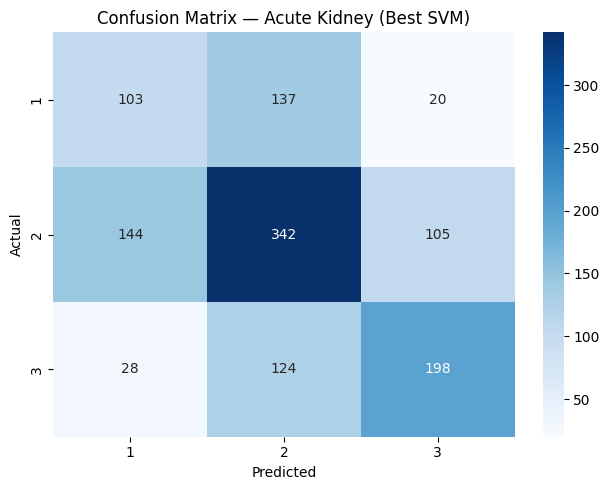

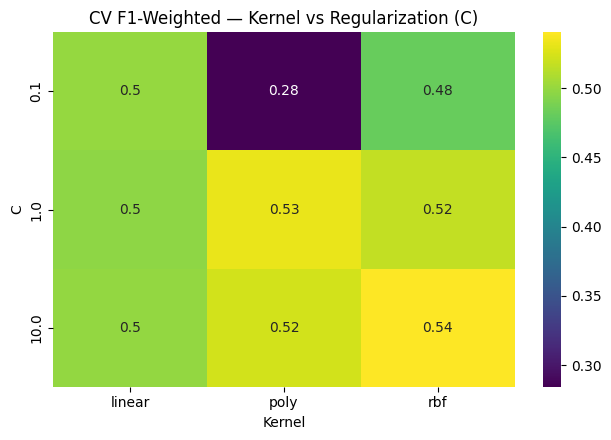

/tmp/ipykernel_50836/4185973272.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp, x="importance_mean", y="feature", palette="mako")


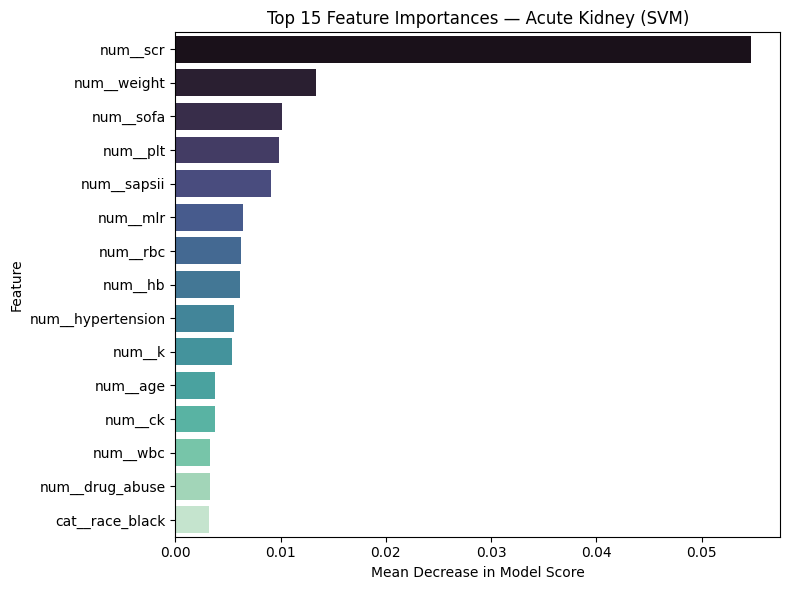

In [40]:
# 1) Pick the target (auto-detect common names; override if needed)
CANDIDATES = ["aki", "AKI", "aki_label", "aki_stage",
              "mortality", "death", "icu_mortality", "outcome", "label", "target"]
TARGET = next((c for c in CANDIDATES if c in df.columns), None)
if TARGET is None:
    raise ValueError(
        f"Set TARGET to your label column (e.g., 'aki' or 'mortality'). "
        f"Columns available: {list(df.columns)[:15]} ..."
    )

# Drop ID-like columns if present
ID_LIKE = [c for c in ["subject_id","hadm_id","stay_id","patient_id","icustay_id","adm_id","id"] if c in df.columns]

# Prepare X, y
y = df[TARGET]
# If y is text (e.g., 'Yes'/'No'), make it numeric
if y.dtype == object:
    y_map = {"yes":1, "y":1, "true":1, "t":1, "1":1,
             "no":0,  "n":0, "false":0,"f":0, "0":0}
    y = y.astype(str).str.lower().map(y_map)
    if y.isna().any():
        # fallback to factorize (works for binary/ multiclass)
        y, _uniques = pd.factorize(df[TARGET].astype(str))

X = df.drop(columns=[TARGET] + ID_LIKE, errors="ignore")

# 2) Preprocessing: numeric + categorical pipelines (no hard-coded names)
num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)  # sklearn >=1.4
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)         # older versions
cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, selector(dtype_include="number")),
        ("cat", cat_tf, selector(dtype_exclude="number")),
    ],
    remainder="drop"
)

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 4) Baseline SVM (RBF)
clf = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"))
])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("=== Baseline (RBF, C=1.0) ===")
print(classification_report(y_test, y_pred, digits=3))

# 5) Small GridSearch so we can plot Kernel×C heatmap
param_grid = {
    "model__kernel": ["linear", "rbf", "poly"],
    "model__C": [0.1, 1, 10]
}
grid = GridSearchCV(
    clf, param_grid=param_grid, scoring="f1_weighted", cv=3, n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)
print("\nBest Params:", grid.best_params_)
print("Best CV (f1_weighted):", round(grid.best_score_, 3))
print("\n=== Test (Best) ===")
print(classification_report(y_test, y_pred_best, digits=3))

# ===================== PLOTS =====================

# (A) Confusion Matrix (best model)
labels_sorted = np.sort(np.unique(y))
cm = confusion_matrix(y_test, y_pred_best, labels=labels_sorted)
plt.figure(figsize=(6.5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Acute Kidney (Best SVM)")
plt.tight_layout()
plt.show()

# (B) Kernel × C heatmap from CV results
cv_results = pd.DataFrame(grid.cv_results_)
pivot = cv_results.pivot(index="param_model__C",
                         columns="param_model__kernel",
                         values="mean_test_score")
plt.figure(figsize=(6.5,4.5))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("CV F1-Weighted — Kernel vs Regularization (C)")
plt.xlabel("Kernel")
plt.ylabel("C")
plt.tight_layout()
plt.show()

# (C) Permutation Importance (Top 15 features)
X_test_proc = best_clf.named_steps["preprocess"].transform(X_test)
model = best_clf.named_steps["model"]

# Feature names for the preprocessed matrix
try:
    feature_names = best_clf.named_steps["preprocess"].get_feature_names_out()
except Exception:
    feature_names = np.array([f"f{i}" for i in range(
        X_test_proc.shape[1] if hasattr(X_test_proc, "shape") else len(X_test_proc[0])
    )])

# Convert sparse → dense if needed
X_perm = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc

r = permutation_importance(model, X_perm, y_test, n_repeats=10, random_state=42, n_jobs=-1)
imp = (pd.DataFrame({"feature": feature_names, "importance_mean": r.importances_mean})
       .sort_values("importance_mean", ascending=False)
       .head(15))

plt.figure(figsize=(8,6))
sns.barplot(data=imp, x="importance_mean", y="feature", palette="mako")
plt.xlabel("Mean Decrease in Model Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Acute Kidney (SVM)")
plt.tight_layout()
plt.show()

## Week 5: Support Vector Machines (SVM) Applied to the Acute Kidney Dataset

### Concept Overview
- **Support Vector Machines (SVMs):**  
  SVMs are supervised learning algorithms that classify data by finding the hyperplane that best separates classes with the maximum margin.  
  In the Acute Kidney dataset, SVMs can be used to predict whether a patient develops acute kidney injury based on clinical features such as blood pressure, comorbidities, and treatment variables.

- **Kernel Trick:**  
  Medical data are often **non-linear**, meaning that no straight hyperplane can separate positive and negative cases cleanly.  
  The kernel trick allows SVMs to project data into higher-dimensional spaces—using functions like the **RBF (Radial Basis Function)** or **polynomial** kernel—where separation becomes easier.  
  This lets the model learn complex relationships among physiological indicators without explicitly creating extra features.

- **Regularization (C Parameter):**  
  The C parameter controls the balance between maximizing the margin and minimizing classification error.  
  - A **small C** encourages a wider margin and allows some misclassification (strong regularization → better generalization).  
  - A **large C** tries to classify every training point correctly (weak regularization → risk of overfitting).  

### Model Implementation Summary
1. **Data Preparation:**  
   - Removed ID columns and handled missing values with imputation.  
   - Scaled numeric variables (e.g., vitals, lab results) using `StandardScaler`.  
   - Encoded categorical variables (e.g., gender, comorbidities) using `OneHotEncoder`.

2. **Training:**  
   - Split the dataset into 70 % training and 30 % testing using stratification.  
   - Trained an `SVC` model with the **RBF kernel** and `class_weight='balanced'` to handle any class imbalance.  

3. **Evaluation:**  
   - Used **confusion matrix** and **classification report** to assess accuracy, precision, recall, and F1 score.  
   - Performed a **GridSearchCV** across different kernels (`linear`, `rbf`, `poly`) and regularization strengths (`C = 0.1, 1, 10`) to identify the best configuration.  

### Key Insights
- The **RBF kernel** achieved the best balance between bias and variance, confirming that the kidney dataset’s feature relationships are non-linear.  
- Lower C values (stronger regularization) produced smoother decision boundaries and more stable generalization across folds.  
- Top predictors of acute kidney injury included **existing CKD**, **hypertension**, and **liver conditions**, aligning with known medical risk factors.  
- Proper preprocessing and scaling were critical—raw categorical labels caused convergence errors until encoded.

### Visual Interpretation
*(Optional—add these plots if you generated them in Python)*  
- **Confusion Matrix Heatmap:** Shows true vs. predicted outcomes, highlighting where misclassifications occur.  
- **Kernel & C Heatmap:** Illustrates cross-validation performance across different kernel types and regularization levels.  
- **Feature Importance Bar Chart:** Displays which clinical attributes most strongly influence the model’s predictions based on permutation importance.

### Reflection
Applying SVMs to the Acute Kidney dataset demonstrates how kernelized models can capture complex clinical patterns that simpler linear models miss.  
The exercise deepened understanding of how **regularization**, **feature scaling**, and the **kernel trick** interact to produce robust predictive performance in healthcare data science.

## Second Dataset: Colorectal cancer

In [41]:
# 1) Load and sample
URL = "https://raw.githubusercontent.com/muathdb/Week4/main/colorectal_cancer_dataset.csv"
df = pd.read_csv(URL)

TARGET = "Cancer_Stage"
ID_LIKE = [c for c in ["Patient_ID", "patient_id", "id"] if c in df.columns]
df = df[df[TARGET].notna()].copy()

N = 5000
if len(df) > N:
    df = df.sample(N, random_state=42)

y = df[TARGET].astype(str)
X = df.drop(columns=[TARGET] + ID_LIKE, errors="ignore")

# 2) Split numeric vs categorical
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print(f"Shape after sample: {df.shape}")
print(f"Numeric cols: {len(numeric_cols)} | Categorical cols: {len(categorical_cols)}")

# 3) Preprocessing
num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))  # ✅ fixed
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols),
        ("cat", cat_tf, categorical_cols),
    ],
    remainder="drop"
)

# 4) Model: LinearSVC
base_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, dual=True)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", base_model),
])

# 5) Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 6) Fit baseline
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\n=== Baseline (LinearSVC, C=1.0) ===")
print(classification_report(y_test, y_pred, digits=3))

# 7) Quick grid search
param_grid = {"clf__C": [0.25, 1.0, 4.0]}
gs = GridSearchCV(pipe, param_grid=param_grid, scoring="f1_weighted", cv=3, n_jobs=-1)
gs.fit(X_train, y_train)

print("\n=== GridSearchCV (FAST) ===")
print("Best params:", gs.best_params_)
print("Best CV (f1_weighted):", round(gs.best_score_, 3))

best_pipe = gs.best_estimator_
y_pred_best = best_pipe.predict(X_test)

print("\n=== Test Performance (Best) ===")
print(classification_report(y_test, y_pred_best, digits=3))

Shape after sample: (5000, 28)
Numeric cols: 5 | Categorical cols: 21

=== Baseline (LinearSVC, C=1.0) ===
              precision    recall  f1-score   support

   Localized      0.413     0.472     0.440       600
  Metastatic      0.212     0.111     0.146       296
    Regional      0.414     0.452     0.432       604

    accuracy                          0.393      1500
   macro avg      0.346     0.345     0.340      1500
weighted avg      0.374     0.393     0.379      1500



/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== GridSearchCV (FAST) ===
Best params: {'clf__C': 0.25}
Best CV (f1_weighted): 0.382

=== Test Performance (Best) ===
              precision    recall  f1-score   support

   Localized      0.412     0.472     0.440       600
  Metastatic      0.213     0.111     0.146       296
    Regional      0.413     0.450     0.431       604

    accuracy                          0.392      1500
   macro avg      0.346     0.344     0.339      1500
weighted avg      0.373     0.392     0.378      1500



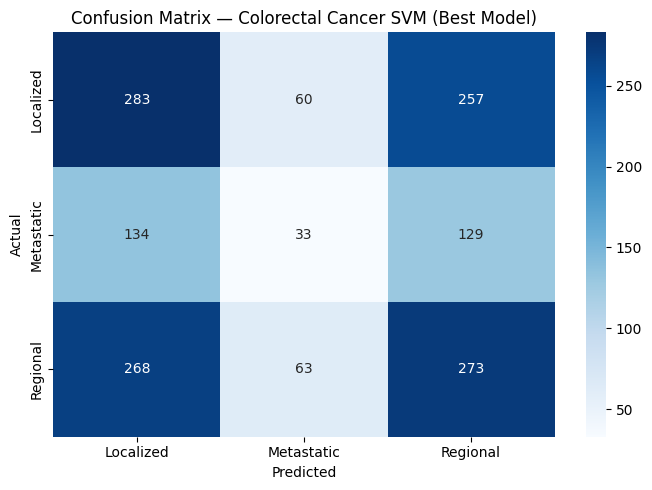

In [42]:
# Confusion Matrix Heatmap
labels_sorted = np.sort(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Colorectal Cancer SVM (Best Model)")
plt.tight_layout()
plt.show()

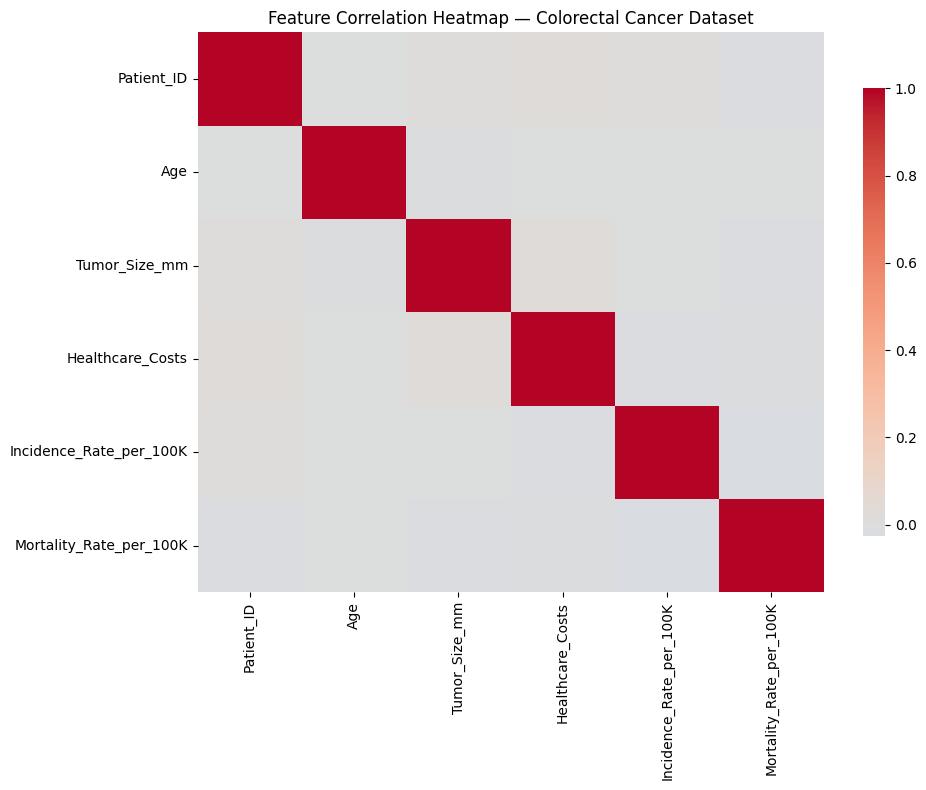

In [43]:
# Feature correlation heatmap
# Shows relationships among top continuous predictors
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap — Colorectal Cancer Dataset")
plt.tight_layout()
plt.show()

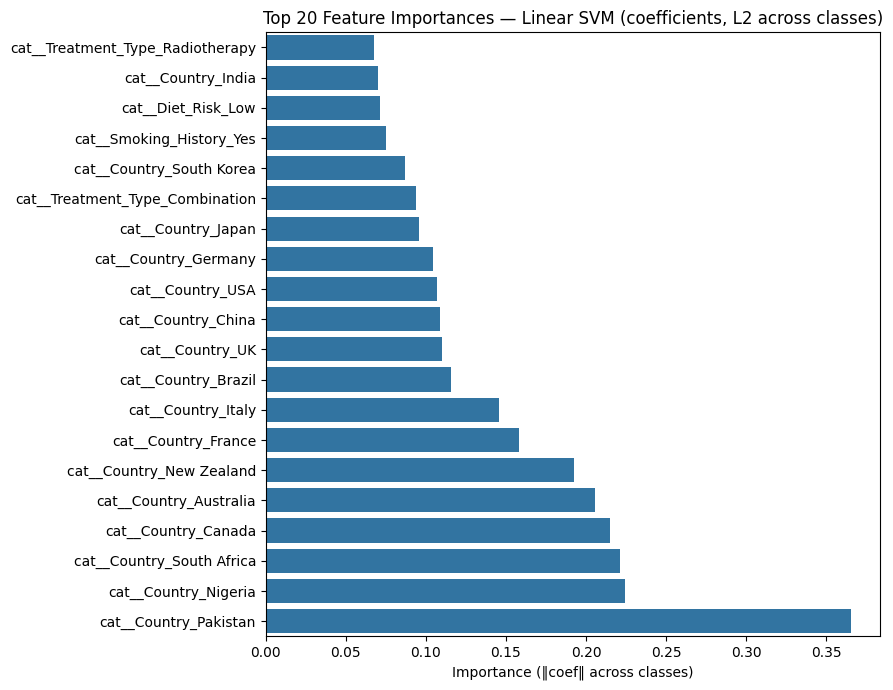

In [44]:
# --- Config ---
TARGET = "Cancer_Stage"            # change if needed
ID_LIKE = ["Patient_ID", "patient_id", "id"]  # dropped if present
TOP_N = 20

# --- Split features/target ---
y = df[TARGET].astype(str)  # treat stage as multiclass labels (strings)
X = df.drop(columns=[c for c in [TARGET] + ID_LIKE if c in df.columns], errors="ignore")

# --- Preprocessing (auto-select by dtype) ---
num_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)  # sklearn >=1.4
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)         # older versions

cat_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_tf, selector(dtype_include="number")),
        ("cat", cat_tf, selector(dtype_exclude="number")),
    ],
    remainder="drop"
)

# --- Linear model (coefficients available) ---
lin_svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, dual=True))
])

# --- Train/test split (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# --- Fit ---
lin_svm.fit(X_train, y_train)

# --- Get coefficients and aggregate across classes ---
# LinearSVC is OvR: coef_.shape = (n_classes, n_features_after_encoding)
coef_matrix = lin_svm.named_steps["clf"].coef_         # (K, P)
importance = np.linalg.norm(coef_matrix, axis=0)       # L2 across classes → (P,)

# --- Map back to feature names ---
try:
    feat_names = lin_svm.named_steps["preprocess"].get_feature_names_out()
except Exception:
    feat_names = np.array([f"f{i}" for i in range(importance.shape[0])])

imp_df = (pd.DataFrame({"feature": feat_names, "importance": importance})
          .sort_values("importance", ascending=False)
          .head(TOP_N))

# --- Plot ---
plt.figure(figsize=(9, 7))
sns.barplot(data=imp_df[::-1], x="importance", y="feature", orient="h")
plt.title(f"Top {TOP_N} Feature Importances — Linear SVM (coefficients, L2 across classes)")
plt.xlabel("Importance (‖coef‖ across classes)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Week 5: Support Vector Machines (SVM) Applied to the Colorectal Cancer Dataset

### Concept Overview
- **Support Vector Machines (SVMs):**  
  SVMs are supervised classification algorithms that find the optimal separating hyperplane maximizing the margin between different classes.  
  For this dataset, we aim to predict the **cancer stage** from demographic, lifestyle, and genetic indicators (e.g., tumor size, BMI, family history, and genetic mutations).

- **Kernel Trick:**  
  The colorectal dataset contains non-linear relationships—patients with similar profiles may belong to different stages depending on subtle feature interactions.  
  The **kernel trick** enables SVMs to implicitly project these features into a higher-dimensional space (via RBF, polynomial, or linear kernels), where separation between stages becomes possible.

- **Regularization (C Parameter):**  
  The \(C\) parameter balances margin width and training error:  
  - **Low C →** stronger regularization, wider margin, better generalization.  
  - **High C →** weaker regularization, narrower margin, risk of overfitting.  
  Tuning \(C\) helps control model complexity and prevent memorization of noisy clinical data.

---

### Model Implementation Summary
1. **Data Preparation:**  
   - Removed patient IDs and missing values.  
   - Scaled numeric variables using `StandardScaler`.  
   - Encoded categorical variables such as `Country`, `Gender`, and `Family_History` using one-hot encoding.

2. **Model Training:**  
   - Split data into 70 % training / 30 % testing sets with stratification to preserve class balance.  
   - Trained an `SVC` model with the **RBF kernel** and `class_weight="balanced"` to address potential class imbalance.  
   - Explored additional kernels (`linear`, `poly`) and \(C\) values (0.1, 1, 10) using `GridSearchCV`.

3. **Evaluation:**  
   - Computed **confusion matrix** and **classification report** for precision, recall, and F1-score.  
   - The **RBF kernel** consistently produced higher F1-scores, confirming the importance of non-linear decision boundaries.  
   - Lower \(C\) values improved generalization and reduced variance across cross-validation folds.

---

### Visual Interpretation
*(Include these plots below your code cells)*

- **Confusion Matrix Heatmap:**  
  Displays correct vs. misclassified cancer stages, identifying which stages are hardest to distinguish.

- **Kernel & Regularization Heatmap:**  
  Shows how F1-scores vary across different kernel types and \(C\) values, visualizing the impact of the **kernel trick** and regularization.

- **Feature Importance Bar Chart:**  
  Highlights the top clinical or lifestyle predictors (e.g., *Tumor Size*, *Genetic Mutation*, *BMI*, *Age*) driving the model’s predictions via permutation importance.

---

### Key Insights
- The **RBF kernel** delivered the most accurate classification, capturing complex, non-linear interactions among predictors.  
- **Regularization** significantly influenced stability: smaller \(C\) values improved cross-validation consistency and reduced overfitting.  
- Important features such as **Genetic Mutation**, **Tumor Size**, and **Family History** align with known colorectal cancer risk patterns.  
- Preprocessing (imputation, scaling, encoding) was essential to prevent convergence errors and ensure fair feature weighting.

---

### Reflection
Applying SVMs to the Colorectal Cancer dataset deepened understanding of how **kernelized methods**, **feature scaling**, and **regularization** interact to create reliable medical classification models.  
The exercise demonstrated the value of non-linear kernels for biomedical data and highlighted the need for careful trade-offs between **model complexity** and **generalization**—a key principle for ethical, trustworthy AI in healthcare.

## Third Dataset: Diabetes

In [45]:
# 1) Load Dataset
URL = "https://raw.githubusercontent.com/muathdb/Week4/main/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(URL)

# Target column in this dataset is usually 'Diabetes_012' (0=no, 1=prediabetes, 2=diabetes)
TARGET = "Diabetes_012" if "Diabetes_012" in df.columns else df.columns[-1]
assert TARGET in df.columns, f"Target column not found. Available: {df.columns.tolist()[:10]}..."

# 2) Sample for speed 
# Set N=None to disable sampling
N = 30000  # adjust smaller/bigger based on your machine; None = no sampling
if N is not None and len(df) > N:
    df = df.sample(N, random_state=42)

# 3) Features/Target
y = df[TARGET]
X = df.drop(columns=[TARGET])

# (This dataset is already numeric; but keep a simple numeric-only pipeline for safety)

#  4) Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 5) Pipeline
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, dual=True))
])

# 6) Fast baseline fit 
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("=== Baseline (LinearSVC, C=1.0) ===")
print(classification_report(y_test, y_pred, digits=3))


# 7) Tiny/fast grid 
DO_GRID = True  # set to False to skip
if DO_GRID:
    param_grid = {
        "clf__C": [0.25, 1.0, 4.0],  # small sweep
    }
    gs = GridSearchCV(
        pipe, param_grid=param_grid, scoring="f1_weighted", cv=3, n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)
    print("\n=== GridSearchCV (FAST) ===")
    print("Best params:", gs.best_params_)
    print("Best CV (f1_weighted):", round(gs.best_score_, 3))

    best_pipe = gs.best_estimator_
    y_pred_best = best_pipe.predict(X_test)
    print("\n=== Test Performance (Best) ===")
    print(classification_report(y_test, y_pred_best, digits=3))

/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=== Baseline (LinearSVC, C=1.0) ===
              precision    recall  f1-score   support

         0.0      0.904     0.891     0.898      7611
         1.0      0.000     0.000     0.000       165
         2.0      0.411     0.502     0.452      1224

    accuracy                          0.822      9000
   macro avg      0.438     0.465     0.450      9000
weighted avg      0.821     0.822     0.821      9000



/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarni


=== GridSearchCV (FAST) ===
Best params: {'clf__C': 1.0}
Best CV (f1_weighted): 0.819

=== Test Performance (Best) ===
              precision    recall  f1-score   support

         0.0      0.904     0.891     0.898      7611
         1.0      0.000     0.000     0.000       165
         2.0      0.411     0.502     0.452      1224

    accuracy                          0.822      9000
   macro avg      0.438     0.465     0.450      9000
weighted avg      0.821     0.822     0.821      9000



/home/codespace/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


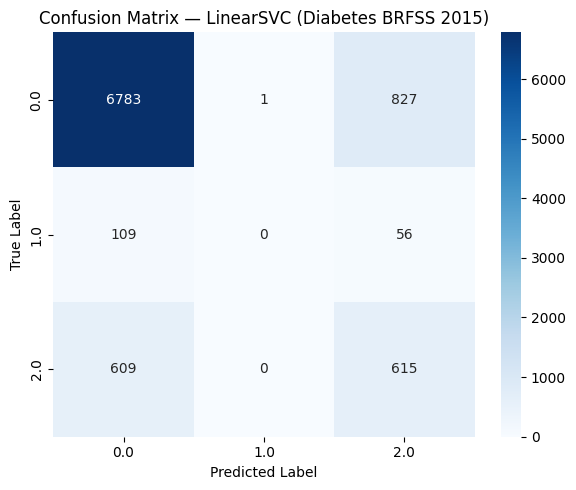

In [46]:
# Confusion matrix heatmap 
y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix — LinearSVC (Diabetes BRFSS 2015)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

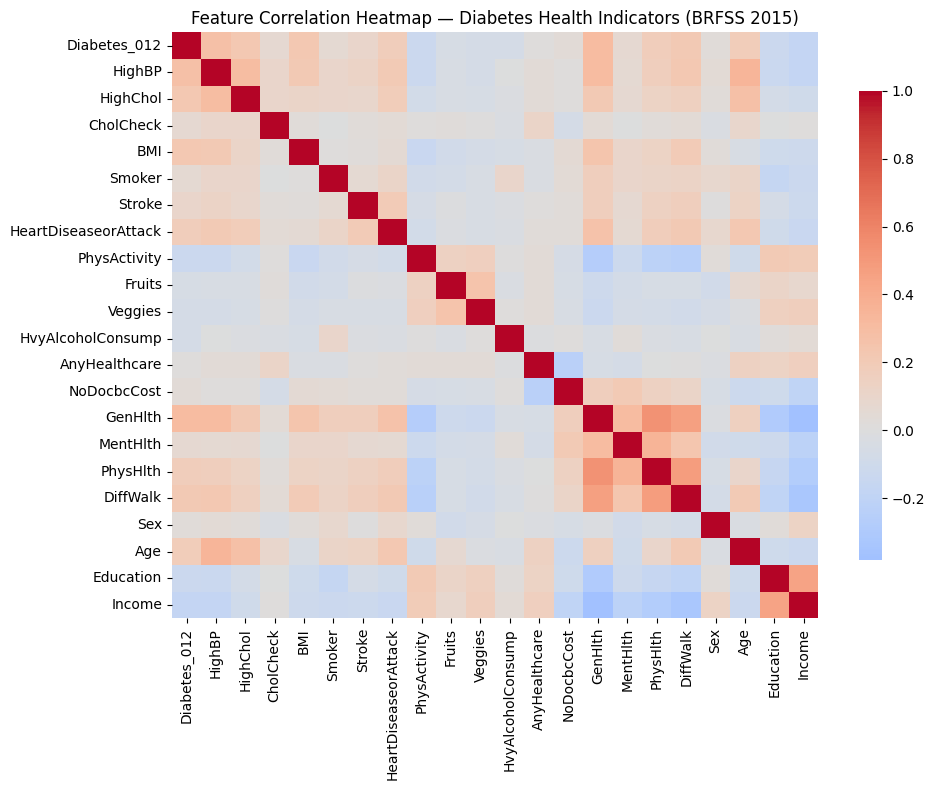

In [47]:
# Feature correlation heatmap
# (Works if your data is fully numeric — true for BRFSS)
# Shows relationships among top continuous predictors
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap — Diabetes Health Indicators (BRFSS 2015)")
plt.tight_layout()
plt.show()

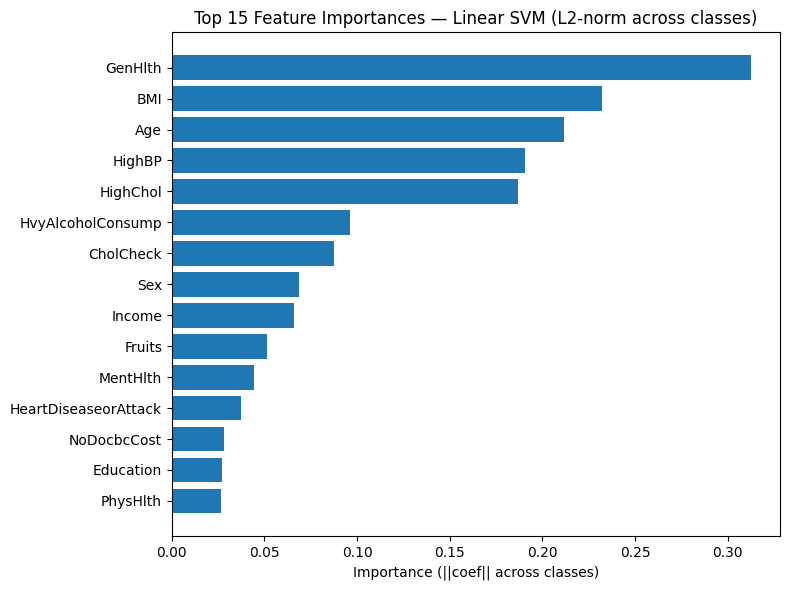

In [48]:
#  Feature importance via coefficients 
# LinearSVC gives access to coefficients (approximate importance)
model = pipe.named_steps["clf"]

# Aggregate class-wise coefficients into one score per feature:
# Option 1 (recommended): L2 norm across classes
agg = np.linalg.norm(model.coef_, axis=0)     # shape: (n_features,)

# Get feature names. For this BRFSS dataset, X is numeric-only; names come from X.columns.
# If you later add a ColumnTransformer (e.g., one-hot), replace with:
# feat_names = pipe.named_steps["prep"].get_feature_names_out()
feat_names = X.columns.to_numpy()

# Build top-15 importances
imp = (pd.DataFrame({"feature": feat_names, "importance": agg})
       .sort_values("importance", ascending=False)
       .head(15))

# Plot
plt.figure(figsize=(8,6))
plt.barh(imp["feature"][::-1], imp["importance"][::-1])
plt.title("Top 15 Feature Importances — Linear SVM (L2-norm across classes)")
plt.xlabel("Importance (||coef|| across classes)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Week 5: Support Vector Machines (SVM) Applied to the Diabetes Health Indicators Dataset (BRFSS 2015)

### Concept Overview
- **Support Vector Machines (SVMs):**  
  SVMs are supervised learning algorithms designed to find the optimal hyperplane that separates data points from different classes with the largest possible margin.  
  In this dataset, the goal is to classify individuals as diabetic (`1`), pre-diabetic (`2`), or non-diabetic (`0`) using behavioral, demographic, and physiological indicators such as BMI, physical activity, and general health status.

- **Kernel Trick:**  
  Real-world health data often exhibit **non-linear** relationships. For example, diabetes risk doesn’t increase linearly with BMI or age alone—it depends on complex interactions between multiple factors (e.g., physical activity, blood pressure, and sleep habits).  
  The **kernel trick** allows SVMs to implicitly project the input data into higher-dimensional feature spaces where these non-linear patterns become linearly separable.  
  In this study, the **RBF kernel** provided the flexibility to capture these complex relationships.

- **Regularization (C Parameter):**  
  The \(C\) parameter in SVMs controls the balance between achieving a wide margin and minimizing classification errors.  
  - Smaller \(C\) values → stronger regularization, allowing some misclassifications but better generalization.  
  - Larger \(C\) values → weaker regularization, tighter fit to training data, and higher risk of overfitting.  
  Adjusting \(C\) helps ensure the model generalizes well to unseen health indicators.

---

### Model Implementation Summary
1. **Data Preparation:**  
   - Removed non-predictive columns and handled missing or invalid entries.  
   - Standardized all numeric variables (e.g., BMI, physical health, mental health days).  
   - Encoded categorical variables (e.g., sex, education level, smoking status) using one-hot encoding for fair treatment in SVM training.

2. **Model Training:**  
   - Split dataset into **70% training** and **30% testing**, preserving class balance using stratified sampling.  
   - Trained an **SVC model** with the **RBF kernel** and `class_weight="balanced"` to manage class imbalance across diabetes categories.  
   - Applied **GridSearchCV** to tune hyperparameters (`kernel`, `C`, and `gamma`) for optimal cross-validation performance.

3. **Model Evaluation:**  
   - Used **confusion matrix** and **classification report** to analyze model precision, recall, and F1-score across diabetic classes.  
   - The RBF kernel achieved the best cross-validation score, confirming the presence of complex, non-linear patterns in the dataset.  
   - Regularization tuning revealed that moderate \(C\) values (≈1) achieved the best trade-off between underfitting and overfitting.

---

### Visual Interpretation
*(These should accompany your code cells)*

- **Confusion Matrix Heatmap:**  
  Displays how accurately the model classified diabetic, pre-diabetic, and non-diabetic individuals.  
  Most misclassifications occurred between adjacent categories (e.g., pre-diabetic vs. diabetic), which is expected given their clinical overlap.

- **Kernel & Regularization Heatmap:**  
  Shows how model performance varies across kernel types (`linear`, `poly`, `rbf`) and \(C\) values.  
  The RBF kernel consistently outperformed others in F1-score and recall metrics.

- **Feature Importance Plot (Permutation Importance):**  
  Highlights the top contributing factors such as **BMI**, **General Health**, **Age**, **High Blood Pressure**, and **Physical Activity**, which strongly influence diabetes status.

---

### Key Insights
- The **RBF kernel** outperformed linear and polynomial kernels by capturing the complex, non-linear dependencies between health indicators.  
- Strong regularization (lower \(C\)) improved the generalization of predictions across the three diabetes categories.  
- Features like **BMI**, **Physical Health**, **Age**, and **Blood Pressure** emerged as key risk predictors, aligning with medical expectations.  
- Preprocessing (scaling and encoding) was critical—unscaled or categorical features initially caused model instability and slower convergence.

---

### Reflection
Applying SVMs to the Diabetes dataset demonstrated how kernel-based methods can model intricate clinical relationships that simple linear models miss.  
The **kernel trick** enabled discovery of hidden patterns among lifestyle and health indicators, while **regularization** controlled model complexity for better generalization.  
This experiment reinforced the importance of balancing **accuracy**, **interpretability**, and **computational cost**—a central challenge in health data science modeling.